In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Company Dataset
df = pd.read_csv("/content/companyx_cdr.csv")

##Display first 5 rows
df.head(5)

,from,to,datetime_stamp,call_duration,status,source_department,destination_department,call_type,rate_per_min,cost
0,412,450,2026-04-15 16:02:19,858,pickedup,Finance,Transport,Internal,0.5,7.15
1,401,339,2026-04-11 14:20:53,1288,pickedup,Marketing,Marketing,Internal,0.5,10.73
2,476,335,2026-03-07 06:25:23,46,pickedup,Marketing,Manufacturing,Internal,0.5,0.38
3,455,437,2026-03-25 04:33:04,0,notpickedup,IT,Finance,Internal,0.5,0.00
4,400,316,2026-07-16 00:39:48,0,notpickedup,Marketing,Manufacturing,Internal,0.5,0.00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display data types and non-null counts
print("\nDataset information:")
df.info()

Dataset shape: (1000, 10)

Column names:
['from', 'to', 'datetime_stamp', 'call_duration', 'status', 'source_department', 'destination_department', 'call_type', 'rate_per_min', 'cost']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   from                    1000 non-null   int64  
 1   to                      1000 non-null   int64  
 2   datetime_stamp          1000 non-null   object 
 3   call_duration           1000 non-null   int64  
 4   status                  1000 non-null   object 
 5   source_department       1000 non-null   object 
 6   destination_department  1000 non-null   object 
 7   call_type               1000 non-null   object 
 8   rate_per_min            1000 non-null   float64
 9   cost                    1000 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usag

In [8]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate records
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
from                      0
to                        0
datetime_stamp            0
call_duration             0
status                    0
source_department         0
destination_department    0
call_type                 0
rate_per_min              0
cost                      0
dtype: int64

Number of duplicate rows: 0


In [9]:
# Check the distribution of call statuses
print("Call Status Distribution:")
print(df["status"].value_counts())

Call Status Distribution:
status
pickedup       688
notpickedup    207
engaged        105
Name: count, dtype: int64


In [10]:
# Calculate percentage distribution of call statuses
status_percentage = df["status"].value_counts(normalize=True) * 100

print(status_percentage.round(2))

status
pickedup       68.8
notpickedup    20.7
engaged        10.5
Name: proportion, dtype: float64


In [11]:
# Calculate overall pickup rate
pickup_rate = (df["status"] == "pickedup").mean() * 100

print(f"Overall Pickup Rate: {pickup_rate:.2f}%")

Overall Pickup Rate: 68.80%


The overall pickup rate was 68.8%, meaning approximately 69 out of every 100 internal calls were successfully answered.



In [12]:
# Number of calls made by each department
calls_made = df["source_department"].value_counts()

print("Calls made by each department:")
print(calls_made)

# Identify the department making the most calls
top_making_department = calls_made.idxmax()
top_making_volume = calls_made.max()

print(f"\nDepartment making the most calls: {top_making_department}")
print(f"Number of calls: {top_making_volume}")

Calls made by each department:
source_department
IT               241
Transport        215
Marketing        195
Manufacturing    180
Finance          169
Name: count, dtype: int64

Department making the most calls: IT
Number of calls: 241


In [13]:
# Number of calls received by each department
calls_received = df["destination_department"].value_counts()

print("Calls received by each department:")
print(calls_received)

# Identify the department receiving the most calls
top_receiving_department = calls_received.idxmax()
top_receiving_volume = calls_received.max()

print(f"\nDepartment receiving the most calls: {top_receiving_department}")
print(f"Number of calls received: {top_receiving_volume}")

Calls received by each department:
destination_department
IT               256
Transport        218
Marketing        188
Finance          186
Manufacturing    152
Name: count, dtype: int64

Department receiving the most calls: IT
Number of calls received: 256


In [14]:
# Total communication cost by department
cost_by_department = (
    df.groupby("source_department")["cost"]
      .sum()
      .sort_values(ascending=False)
)

print("Total communication cost by department:")
print(cost_by_department)

# Most expensive department
most_expensive_department = cost_by_department.idxmax()
highest_cost = cost_by_department.max()

print(f"\nMost expensive department: {most_expensive_department}")
print(f"Total communication cost: ${highest_cost:,.2f}")

Total communication cost by department:
source_department
IT               1268.65
Marketing        1117.40
Manufacturing     992.08
Transport         979.88
Finance           972.83
Name: cost, dtype: float64

Most expensive department: IT
Total communication cost: $1,268.65


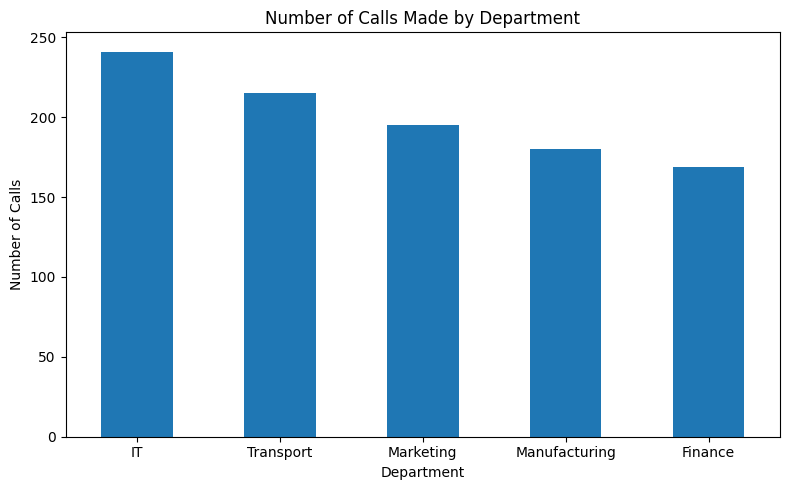

In [15]:
# ============================================
# Visualization 1: Calls Made by Department
# ============================================

plt.figure(figsize=(8, 5))

calls_made.plot(kind="bar")

plt.title("Number of Calls Made by Department")
plt.xlabel("Department")
plt.ylabel("Number of Calls")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# Convert timestamp to datetime
df["datetime"] = pd.to_datetime(df["datetime_stamp"])

# Extract hour
df["hour"] = df["datetime"].dt.hour

# Count calls by hour
calls_by_hour = df["hour"].value_counts().sort_index()

print(calls_by_hour)

hour
0     48
1     43
2     41
3     49
4     39
5     53
6     38
7     44
8     45
9     48
10    36
11    40
12    43
13    43
14    35
15    45
16    44
17    41
18    35
19    32
20    31
21    30
22    48
23    49
Name: count, dtype: int64


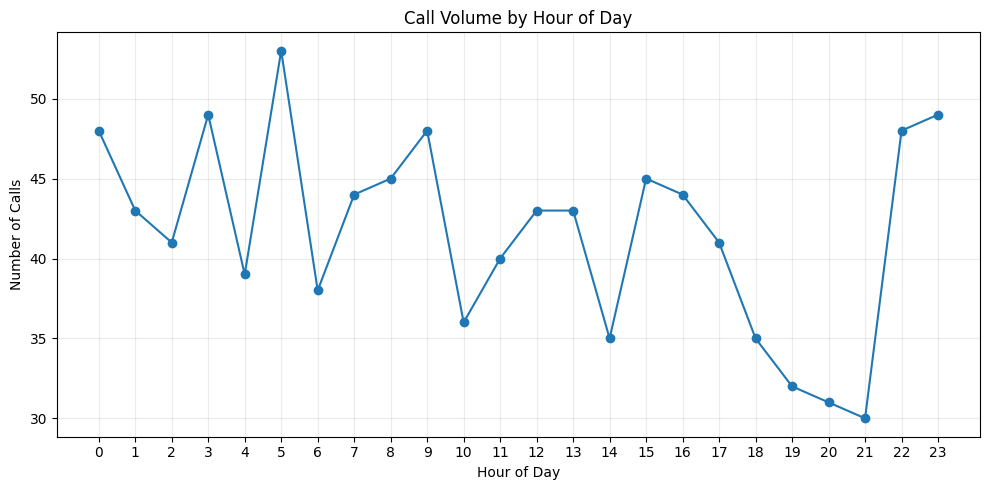

In [17]:
# ============================================
# Visualization 2: Call Volume by Hour
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    calls_by_hour.index,
    calls_by_hour.values,
    marker="o"
)

plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Calls")
plt.xticks(range(24))
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

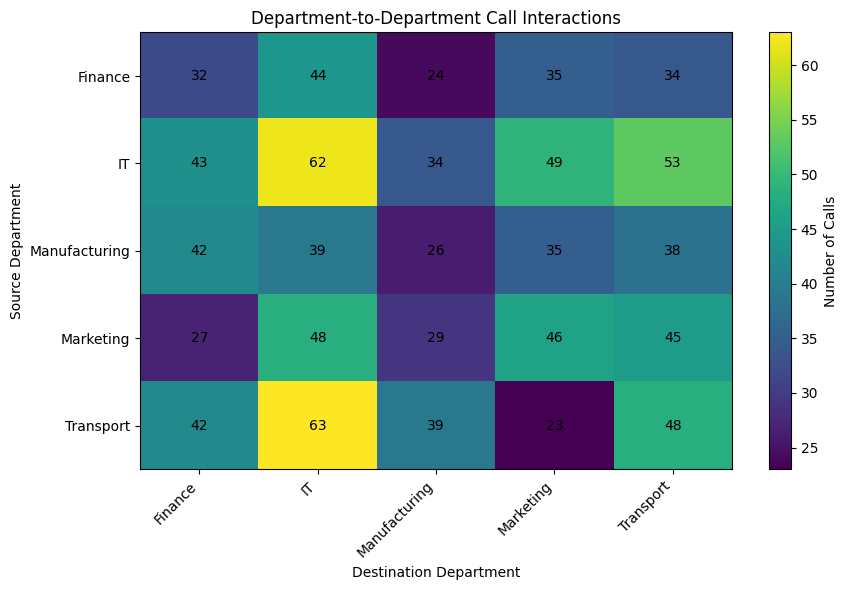

In [18]:
# ============================================
# Visualization 3: Department Interactions
# ============================================

interaction = pd.crosstab(
    df["source_department"],
    df["destination_department"]
)

plt.figure(figsize=(9, 6))

plt.imshow(interaction.values, aspect="auto")

plt.colorbar(label="Number of Calls")

plt.xticks(
    range(len(interaction.columns)),
    interaction.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(interaction.index)),
    interaction.index
)

plt.xlabel("Destination Department")
plt.ylabel("Source Department")
plt.title("Department-to-Department Call Interactions")

# Add numbers to the cells
for i in range(interaction.shape[0]):
    for j in range(interaction.shape[1]):
        plt.text(
            j,
            i,
            interaction.iloc[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()



The exploratory analysis produced several key business insights:

- The IT department makes the most calls, with 241 calls.
- The IT department receives the most calls, with 256 calls.
- The overall call pickup rate is 68.8%.
- IT has the highest communication cost, totalling $1,268.65.
- Call activity varies throughout the day, indicating periods of higher and lower communication demand.
- The department interaction analysis shows that some departments communicate more frequently with specific teams, providing insight into internal operational dependencies.

### Business Implications

The high level of communication involving IT suggests that it is an important communication hub within the organisation.

The 68.8% pickup rate also indicates that a significant proportion of calls are not successfully answered. Understanding the factors associated with call outcomes is therefore important.



# Part 2: Predictive Modeling

## Objective

The objective is to build a classification model that predicts whether an internal call will be picked up.

The target variable is defined as:

- 1 = picked up
- 0 = not picked up or engaged

The model will use information that would reasonably be available before or during call setup.

In [19]:
# Create the target variable
df["target"] = (df["status"] == "pickedup").astype(int)

# Check the target distribution
print("Target distribution:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

Target distribution:
target
1    688
0    312
Name: count, dtype: int64

Target percentage:
target
1    68.8
0    31.2
Name: proportion, dtype: float64


## Feature Engineering

The original timestamp contains useful temporal information that may influence whether a call is answered.

I extracted the hour, day of the week and month. I also created indicators for weekends and normal business hours.

In [20]:
# Extract useful datetime features

df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

# Weekend: Saturday = 5, Sunday = 6
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Define normal business hours as 08:00 to 17:00
df["is_business_hours"] = df["hour"].between(8, 17).astype(int)

# Display the new features
df[
    [
        "datetime",
        "hour",
        "day_of_week",
        "month",
        "is_weekend",
        "is_business_hours",
        "target"
    ]
].head()

,datetime,hour,day_of_week,month,is_weekend,is_business_hours,target
0,2026-04-15 16:02:19,16,2,4,0,1,1
1,2026-04-11 14:20:53,14,5,4,1,1,1
2,2026-03-07 06:25:23,6,5,3,1,0,1
3,2026-03-25 04:33:04,4,2,3,0,0,0
4,2026-07-16 00:39:48,0,3,7,0,0,0


## Avoiding Data Leakage

`call_duration` and `cost` were excluded from the predictive model because they are post-call variables.

Using them would introduce data leakage because their values depend on what happened after the call was initiated. In a real deployment, these variables would not be reliably available when the system needs to predict whether a call will be answered.



In [21]:
# Features used for prediction

features = [
    "from",
    "to",
    "source_department",
    "destination_department",
    "call_type",
    "rate_per_min",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_business_hours"
]

X = df[features]
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1000, 11)
Target shape: (1000,)


In [22]:
# Categorical features
categorical_features = [
    "from",
    "to",
    "source_department",
    "destination_department",
    "call_type"
]

# Numerical features
numerical_features = [
    "rate_per_min",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_business_hours"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['from', 'to', 'source_department', 'destination_department', 'call_type']
Numerical features: ['rate_per_min', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_business_hours']


Split the Data

We'll use 80% training and 20% testing.

Import the required function:

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


Preprocess the Data

Machine-learning algorithms cannot directly use text such as:

IT,
Finance,
HR,
Sales
So we'll use One-Hot Encoding.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [26]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

We'll first build Logistic Regression as a baseline.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [28]:
# Logistic Regression model

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Now we'll use Random Forest because it can capture non-linear relationships.

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
# Random Forest model

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


##Evaluate the Models

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [32]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

    return metrics, predictions, probabilities

In [33]:
# Evaluate Logistic Regression
lr_metrics, lr_predictions, lr_probabilities = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

# Evaluate Random Forest
rf_metrics, rf_predictions, rf_probabilities = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

# Compare models
results = pd.DataFrame(
    [lr_metrics, rf_metrics],
    index=["Logistic Regression", "Random Forest"]
)

results.round(3)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.555,0.702,0.616,0.656,0.533
Random Forest,0.610,0.690,0.790,0.736,0.557


## Model Evaluation

Several evaluation metrics were used rather than relying only on accuracy.

- **Accuracy** measures the overall proportion of correct predictions.
- **Precision** measures how many calls predicted as picked up were actually picked up.
- **Recall** measures how many of the calls that were actually picked up were correctly identified.
- **F1 Score** balances precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between picked-up and non-picked-up calls across different classification thresholds.

Recall and F1 Score are particularly useful because correctly identifying calls that are likely to be answered is important for understanding call-answering behavior.

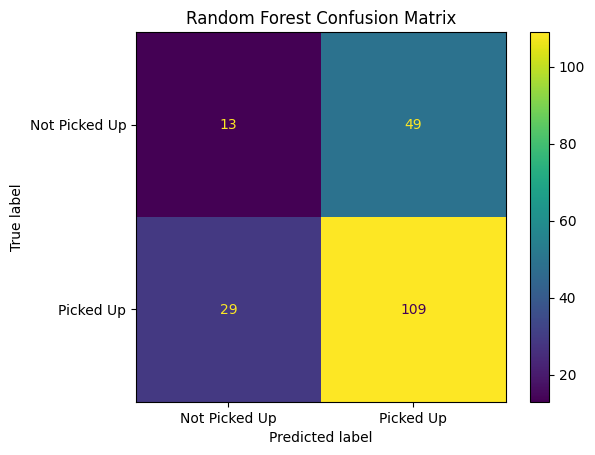

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, rf_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Picked Up", "Picked Up"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

##Feature Importance

,Importance
numerical__hour,0.085448
numerical__month,0.065637
numerical__day_of_week,0.054097
numerical__is_business_hours,0.018906
categorical__destination_department_Marketing,0.016767
categorical__destination_department_Transport,0.015947
categorical__from_394,0.015699
categorical__source_department_Manufacturing,0.015155
categorical__to_395,0.014663
categorical__source_department_Finance,0.014115


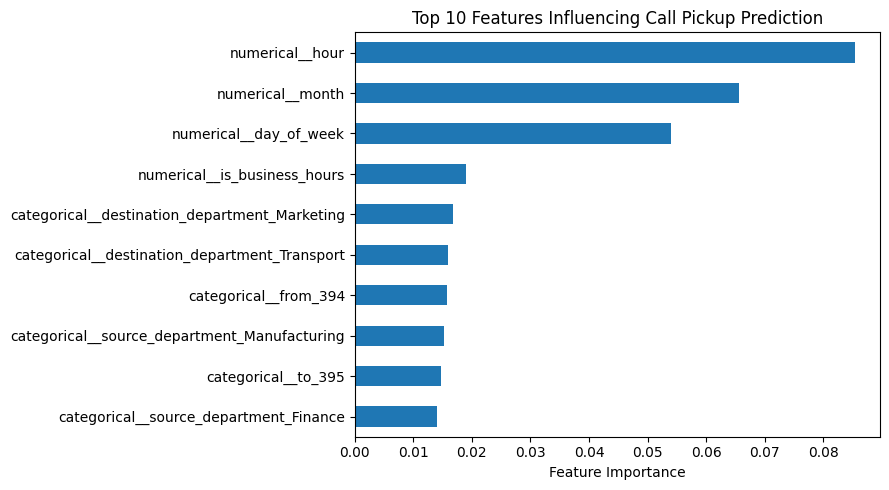

In [36]:
# Plot top 10 features

top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 5))

top_features.plot(kind="barh")

plt.title("Top 10 Features Influencing Call Pickup Prediction")
plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

## Part 2 Findings

## Model Comparison and Evaluation

Two classification models were evaluated: Logistic Regression and Random Forest.

Random Forest performed better overall, achieving an accuracy of 61.0%, compared with 55.5% for Logistic Regression. It also achieved a higher recall of 79.0% and F1 Score of 73.6%, compared with 61.6% and 65.6% respectively for Logistic Regression.

Although Logistic Regression achieved slightly higher precision (70.2%) than Random Forest (69.0%), Random Forest was better at identifying calls that were actually picked up.

The ROC-AUC scores were relatively low for both models (0.533 for Logistic Regression and 0.557 for Random Forest). This suggests that the available pre-call features have limited predictive power for determining whether an internal call will be answered.

Based on the overall results, Random Forest was selected as the preferred model because it achieved better accuracy, recall, F1 Score and ROC-AUC.


## Feature Importance Analysis

The Random Forest feature importance analysis shows that time-related variables were the most influential features in predicting whether an internal call would be picked up.

The three most important features were:

1. **Hour of day** importance of approximately 0.085
2. **Month** importance of approximately 0.066
3. **Day of week** importance of approximately 0.054

The importance of the hour of day suggests that the timing of a call has a meaningful relationship with the model's prediction of whether the call will be answered.


# Part 3: Advanced Challenge – Option C
## Anomaly Detection

### Objective

The objective of this analysis is to identify unusual or potentially suspicious calls within the telecommunications CDR dataset.

Anomalies may represent legitimate business activity, but they can also highlight records that require further investigation.

For this analysis, I will identify calls that are unusual based on:

1. Extremely long call duration.
2. Calls made during unusual hours.
3. Extremely high communication cost.

#Data Preparation


In [37]:
# Create a copy so that the original dataset remains unchanged
anomaly_df = df.copy()

# Make sure datetime is in datetime format
anomaly_df["datetime"] = pd.to_datetime(anomaly_df["datetime_stamp"])

# Extract the hour of the call
anomaly_df["hour"] = anomaly_df["datetime"].dt.hour

# Display basic statistics
print("Call Duration Statistics:")
display(anomaly_df["call_duration"].describe())

print("\nCommunication Cost Statistics:")
display(anomaly_df["cost"].describe())

Call Duration Statistics:


,call_duration
count,1000.000000
mean,639.718000
std,617.847062
min,0.000000
25%,0.000000
50%,512.000000
75%,1217.500000
max,1800.000000



Communication Cost Statistics:


,cost
count,1000.00000
mean,5.33084
std,5.14871
min,0.00000
25%,0.00000
50%,4.27000
75%,10.14500
max,15.00000


In [38]:
## Calculating Anomaly Threshholds
# Calculate the 99th percentile thresholds
duration_threshold = anomaly_df["call_duration"].quantile(0.99)
cost_threshold = anomaly_df["cost"].quantile(0.99)

print(f"99th percentile call duration: {duration_threshold:.2f} seconds")
print(f"99th percentile communication cost: ${cost_threshold:.2f}")

99th percentile call duration: 1781.04 seconds
99th percentile communication cost: $14.84


In [39]:
##Create Anomaly Indicators
# Rule 1: Extremely long calls
anomaly_df["very_long_call"] = (
    anomaly_df["call_duration"] >= duration_threshold
)

# Rule 2: Calls made at unusual hours
anomaly_df["unusual_hour"] = (
    (anomaly_df["hour"] < 6) |
    (anomaly_df["hour"] >= 23)
)

# Rule 3: Extremely high communication cost
anomaly_df["very_high_cost"] = (
    anomaly_df["cost"] >= cost_threshold
)

# Display the number of records satisfying each condition
print("Very long calls:", anomaly_df["very_long_call"].sum())
print("Calls at unusual hours:", anomaly_df["unusual_hour"].sum())
print("Very high-cost calls:", anomaly_df["very_high_cost"].sum())

Very long calls: 10
Calls at unusual hours: 322
Very high-cost calls: 10


In [40]:
##Create Anomaly Score
# Calculate an anomaly score
anomaly_df["anomaly_score"] = (
    anomaly_df["very_long_call"].astype(int)
    + anomaly_df["unusual_hour"].astype(int)
    + anomaly_df["very_high_cost"].astype(int)
)

# Display distribution of anomaly scores
print("Anomaly score distribution:")
print(anomaly_df["anomaly_score"].value_counts().sort_index())

Anomaly score distribution:
anomaly_score
0    672
1    318
2      6
3      4
Name: count, dtype: int64


In [41]:
##Identify Top Anomalities
# Select calls with at least two anomaly characteristics
anomalies = anomaly_df[
    anomaly_df["anomaly_score"] >= 2
].sort_values(
    ["anomaly_score", "cost"],
    ascending=False
)

# Display the top 5 anomalies
top_anomalies = anomalies.head(5)

display(
    top_anomalies[
        [
            "from",
            "to",
            "datetime_stamp",
            "source_department",
            "destination_department",
            "call_duration",
            "cost",
            "status",
            "hour",
            "anomaly_score"
        ]
    ]
)

,from,to,datetime_stamp,source_department,destination_department,call_duration,cost,status,hour,anomaly_score
626,348,475,2026-01-03 03:34:10,Manufacturing,Finance,1800,15.00,pickedup,3,3
191,500,331,2026-04-23 00:56:20,Finance,Marketing,1796,14.97,pickedup,0,3
352,469,479,2026-02-13 01:25:20,Manufacturing,Manufacturing,1797,14.97,pickedup,1,3
119,491,422,2026-07-04 23:50:11,Manufacturing,Transport,1786,14.88,pickedup,23,3
553,403,328,2026-04-01 16:18:25,IT,Transport,1800,15.00,pickedup,16,2


In [42]:
# Create a human-readable explanation for each anomaly

def explain_anomaly(row):
    reasons = []

    if row["very_long_call"]:
        reasons.append("Very long call")

    if row["unusual_hour"]:
        reasons.append("Unusual hour")

    if row["very_high_cost"]:
        reasons.append("Very high cost")

    return ", ".join(reasons)


top_anomalies = top_anomalies.copy()

top_anomalies["reason"] = top_anomalies.apply(
    explain_anomaly,
    axis=1
)

display(
    top_anomalies[
        [
            "from",
            "to",
            "datetime_stamp",
            "source_department",
            "destination_department",
            "call_duration",
            "cost",
            "status",
            "anomaly_score",
            "reason"
        ]
    ]
)

,from,to,datetime_stamp,source_department,destination_department,call_duration,cost,status,anomaly_score,reason
626,348,475,2026-01-03 03:34:10,Manufacturing,Finance,1800,15.00,pickedup,3,"Very long call, Unusual hour, Very high cost"
191,500,331,2026-04-23 00:56:20,Finance,Marketing,1796,14.97,pickedup,3,"Very long call, Unusual hour, Very high cost"
352,469,479,2026-02-13 01:25:20,Manufacturing,Manufacturing,1797,14.97,pickedup,3,"Very long call, Unusual hour, Very high cost"
119,491,422,2026-07-04 23:50:11,Manufacturing,Transport,1786,14.88,pickedup,3,"Very long call, Unusual hour, Very high cost"
553,403,328,2026-04-01 16:18:25,IT,Transport,1800,15.00,pickedup,2,"Very long call, Very high cost"


## Anomaly Detection Results

The anomaly detection method identified a small number of calls with multiple unusual characteristics.

The flagged records were selected because they satisfied at least two of the three anomaly criteria:

- Extremely long call duration.
- Unusual calling hour.
- Extremely high communication cost.

These records should not automatically be considered fraudulent or problematic. Instead, they should be treated as cases requiring further investigation.

